<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_S3_U3_Clase2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Minería de Datos — Unidad 3 · Clase 2
## Laboratorio: Análisis Exploratorio y Multivariado de Datos

**Tecnicatura en Cs de Datos e IA — Politécnico Malvinas Argentinas — 2026**

---

### Objetivos del laboratorio

- Construir una función reutilizable de análisis univariado
- Calcular e interpretar sesgo (skewness) y curtosis (kurtosis)
- Analizar relaciones bivariadas: numérica×numérica, numérica×categórica, categórica×categórica
- Calcular e interpretar coeficientes de correlación (Pearson y Spearman)
- Crear un heatmap de correlación y un pairplot multivariado
- Sintetizar hallazgos de EDA en conclusiones accionables

### Datasets
- **Titanic** — dataset familiar con variables de todos los tipos
- **Iris** — dataset estrella para análisis multivariado (4 variables numéricas, 3 clases)

---
## 📦 Sección 1: Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='Set2')

print('Setup completo.')

Setup completo.


In [ ]:
# Cargar Titanic
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url_titanic)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:


# Conversiones de tipos (de la Unidad 2)
df['Survived'] = df['Survived'].astype(bool)
df['Pclass']   = df['Pclass'].astype('category')
df['Sex']      = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

# Cargar Iris (desde seaborn)
iris = sns.load_dataset('iris')

print(f'Titanic: {df.shape}  |  Iris: {iris.shape}')
df.head(3)

Titanic: (891, 12)  |  Iris: (150, 5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


---
## 📊 Sección 2: Análisis univariado avanzado

### 2.1 Sesgo (skewness) y curtosis (kurtosis)

In [ ]:
# Calcular sesgo y curtosis para variables numéricas
cols_num = ['Age', 'Fare', 'SibSp', 'Parch']

resumen = pd.DataFrame({
    'Media':    df[cols_num].mean().round(2),
    'Mediana':  df[cols_num].median().round(2),
    'Sesgo':    df[cols_num].skew().round(3),
    'Curtosis': df[cols_num].kurtosis().round(3),
    'Nulos':    df[cols_num].isnull().sum(),
})

print('Resumen estadístico avanzado:')
print(resumen)

Resumen estadístico avanzado:
       Media  Mediana  Sesgo  Curtosis  Nulos
Age    29.70    28.00  0.389     0.178    177
Fare   32.20    14.45  4.787    33.398      0
SibSp   0.52     0.00  3.695    17.880      0
Parch   0.38     0.00  2.749     9.778      0


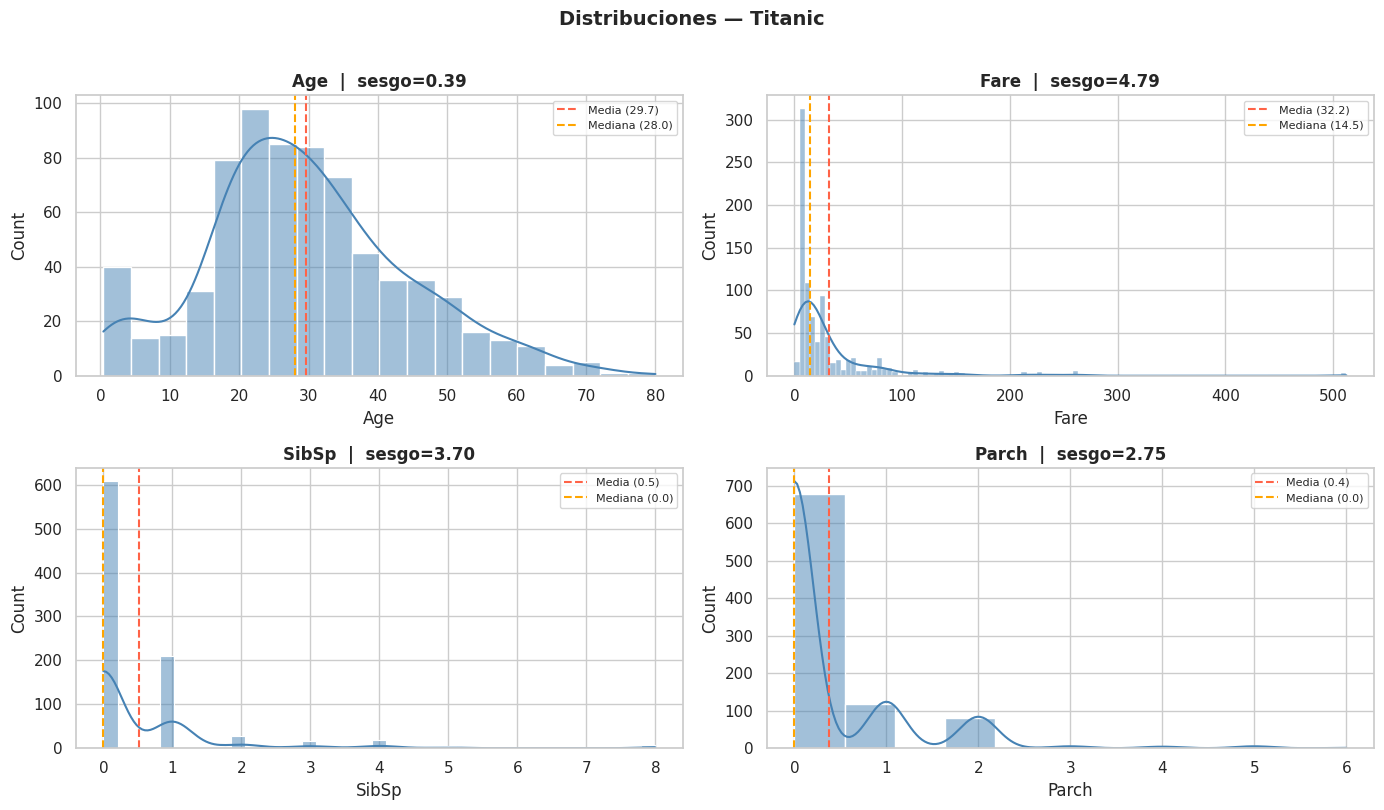

Interpretación del sesgo:
  |sesgo| < 0.5: aproximadamente simétrica
  0.5 < |sesgo| < 1: moderadamente sesgada
  |sesgo| > 1: fuertemente sesgada


In [ ]:
# Visualizar distribuciones con histograma + KDE
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue')
    media   = df[col].mean()
    mediana = df[col].median()
    skew_v  = df[col].skew()
    axes[i].axvline(media,   color='tomato',  linestyle='--', lw=1.5,
                    label=f'Media ({media:.1f})')
    axes[i].axvline(mediana, color='orange',  linestyle='--', lw=1.5,
                    label=f'Mediana ({mediana:.1f})')
    axes[i].set_title(f'{col}  |  sesgo={skew_v:.2f}', fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuciones — Titanic', y=1.01, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('Interpretación del sesgo:')
print('  |sesgo| < 0.5: aproximadamente simétrica')
print('  0.5 < |sesgo| < 1: moderadamente sesgada')
print('  |sesgo| > 1: fuertemente sesgada')

### ✏️ Actividad 1: Interpretar distribuciones

Mirando el resumen y los gráficos de arriba, respondé:

1. ¿Qué variable tiene la distribución más sesgada? ¿Hacia qué lado?
2. Para `Age`: la media y la mediana son similares. ¿Qué indica eso?
3. `Fare` tiene sesgo positivo muy alto (≈4.78). ¿Cuál es la consecuencia práctica de eso para el modelado?

*Escribí tus respuestas como texto en esta celda Markdown o en la celda de abajo.*

In [ ]:
# TODO: Calculá el sesgo y curtosis para el dataset Iris
# ¿Qué variable de Iris tiene la distribución más sesgada?

# cols_iris = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
# resumen_iris = pd.DataFrame({...})
pass

### 2.2 Análisis univariado de variables categóricas

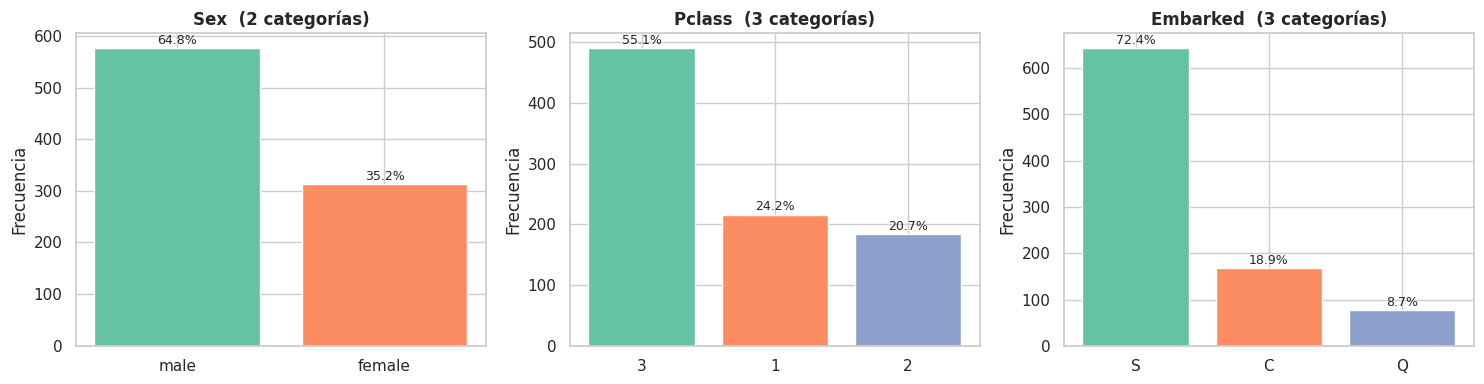

In [ ]:
# Frecuencia de variables categóricas
cats = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cats):
    freq = df[col].value_counts()
    freq_pct = df[col].value_counts(normalize=True) * 100

    axes[i].bar(freq.index.astype(str), freq.values,
                color=sns.color_palette('Set2', len(freq)))
    axes[i].set_title(f'{col}  ({df[col].nunique()} categorías)', fontweight='bold')
    axes[i].set_ylabel('Frecuencia')

    # Agregar porcentajes sobre las barras
    for j, (val, pct) in enumerate(zip(freq.values, freq_pct.values)):
        axes[i].text(j, val + 2, f'{pct:.1f}%',
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 🛠️ Sección 3: Función reutilizable `eda_columna()`

Una función que analiza automáticamente cualquier columna del DataFrame:

In [ ]:
def eda_columna(df, col, figsize=(12, 4)):
    '''
    Analiza una columna del DataFrame.
    - Numerica: estadisticas + histograma + boxplot
    - Categorica: frecuencias + barplot
    '''
    dtype = df[col].dtype
    nulos = df[col].isnull().sum()
    pct_nulos = nulos / len(df) * 100

    print(f'COLUMNA: {col}')
    print(f'  Tipo dtype: {dtype}')
    print(f'  Valores nulos: {nulos} ({pct_nulos:.1f}%)')
    print(f'  Valores únicos: {df[col].nunique()}')
    print()

    is_numeric = pd.api.types.is_numeric_dtype(dtype)

    if is_numeric:
        # Estadísticas numéricas
        serie = df[col].dropna()
        print(f'  Media:    {serie.mean():.3f}')
        print(f'  Mediana:  {serie.median():.3f}')
        print(f'  Std:      {serie.std():.3f}')
        print(f'  Sesgo:    {serie.skew():.3f}')
        print(f'  Curtosis: {serie.kurtosis():.3f}')
        Q1 = serie.quantile(0.25)  ;  Q3 = serie.quantile(0.75)
        print(f'  IQR:      {Q3 - Q1:.3f}')
        print()

        fig, axes = plt.subplots(1, 2, figsize=figsize)
        sns.histplot(serie, kde=True, ax=axes[0], color='steelblue')
        axes[0].axvline(serie.mean(),   color='tomato', linestyle='--', label='Media')
        axes[0].axvline(serie.median(), color='orange', linestyle='--', label='Mediana')
        axes[0].set_title(f'Histograma de {col}', fontweight='bold')
        axes[0].legend()

        axes[1].boxplot(serie, patch_artist=True,
                        boxprops={'facecolor':'steelblue','alpha':0.7},
                        medianprops={'color':'tomato','lw':2})
        axes[1].set_title(f'Boxplot de {col}', fontweight='bold')

    else:
        # Estadísticas categóricas
        freq = df[col].value_counts()
        print(df[col].describe())
        print()

        fig, ax = plt.subplots(figsize=(figsize[0]//2, figsize[1]))
        ax.barh(freq.index.astype(str), freq.values, color=sns.color_palette('Set2', len(freq)))
        ax.set_title(f'Frecuencias de {col}', fontweight='bold')
        ax.set_xlabel('Frecuencia')

    plt.tight_layout()
    plt.show()

print('Función eda_columna() definida.')

Función eda_columna() definida.


COLUMNA: Age
  Tipo dtype: float64
  Valores nulos: 177 (19.9%)
  Valores únicos: 88

  Media:    29.699
  Mediana:  28.000
  Std:      14.526
  Sesgo:    0.389
  Curtosis: 0.178
  IQR:      17.875



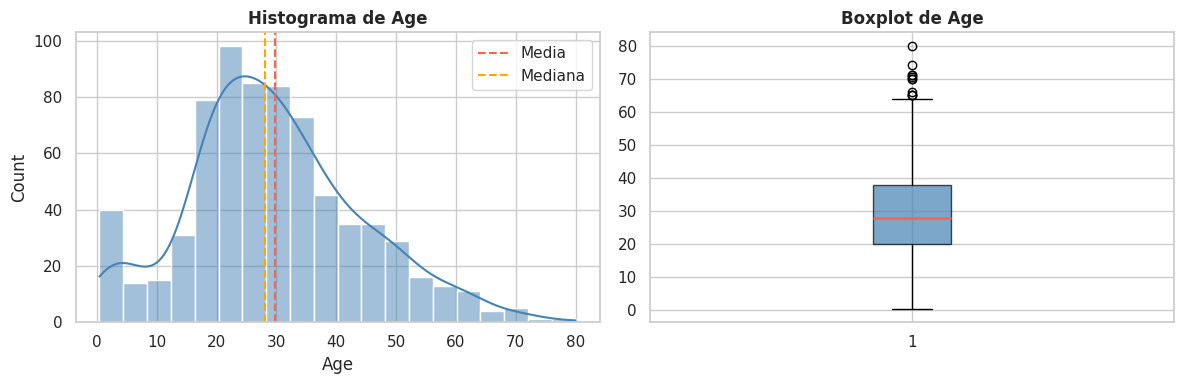

In [ ]:
# Probar la función con Age
eda_columna(df, 'Age')

In [ ]:
# Calcular sesgo y curtosis para variables numéricas
cols_num = ['Age', 'Fare', 'SibSp', 'Parch']

resumen = pd.DataFrame({
    'Media':    df[cols_num].mean().round(2),
    'Mediana':  df[cols_num].median().round(2),
    'Sesgo':    df[cols_num].skew().round(3),
    'Curtosis': df[cols_num].kurtosis().round(3),
    'Nulos':    df[cols_num].isnull().sum(),
})

print('Resumen estadístico avanzado:')
print(resumen)

Resumen estadístico avanzado:
       Media  Mediana  Sesgo  Curtosis  Nulos
Age    29.70    28.00  0.389     0.178    177
Fare   32.20    14.45  4.787    33.398      0
SibSp   0.52     0.00  3.695    17.880      0
Parch   0.38     0.00  2.749     9.778      0


COLUMNA: Fare
  Tipo dtype: float64
  Valores nulos: 0 (0.0%)
  Valores únicos: 248

  Media:    32.204
  Mediana:  14.454
  Std:      49.693
  Sesgo:    4.787
  Curtosis: 33.398
  IQR:      23.090



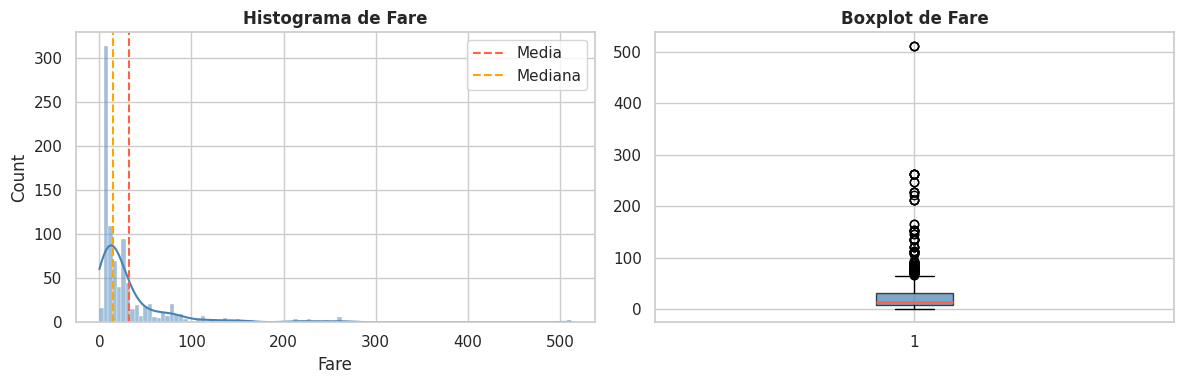

In [ ]:
# Probar la función con Fare
eda_columna(df, 'Fare')

COLUMNA: Sex
  Tipo dtype: category
  Valores nulos: 0 (0.0%)
  Valores únicos: 2

count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object



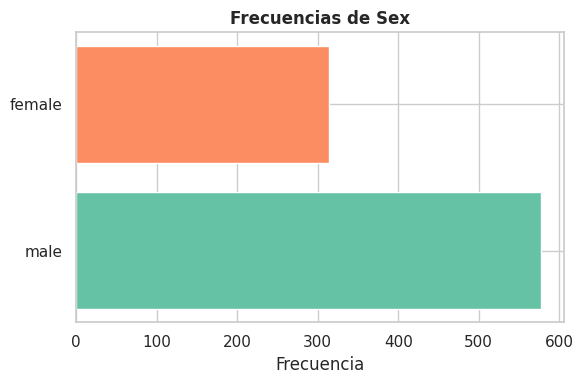

In [ ]:
# Probar la función con Sex (categórica)
eda_columna(df, 'Sex')

### ✏️ Actividad 2: Usar `eda_columna()`

Aplicá la función `eda_columna()` a **tres columnas** del dataset Iris:
`petal_length`, `petal_width`, y `species`.

¿Qué diferencias notás entre las distribuciones numéricas de Iris y las del Titanic?

In [ ]:
# TODO: Aplicar eda_columna() a columnas del dataset Iris
# eda_columna(iris, 'petal_length')
# eda_columna(iris, 'petal_width')
# eda_columna(iris, 'species')
pass

---
## 🔗 Sección 4: Bivariado — Numérica × Numérica

### 4.1 Scatter plots

/tmp/ipykernel_1306/1753156965.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pclass, grupo in df.dropna(subset=['Age']).groupby('Pclass'):


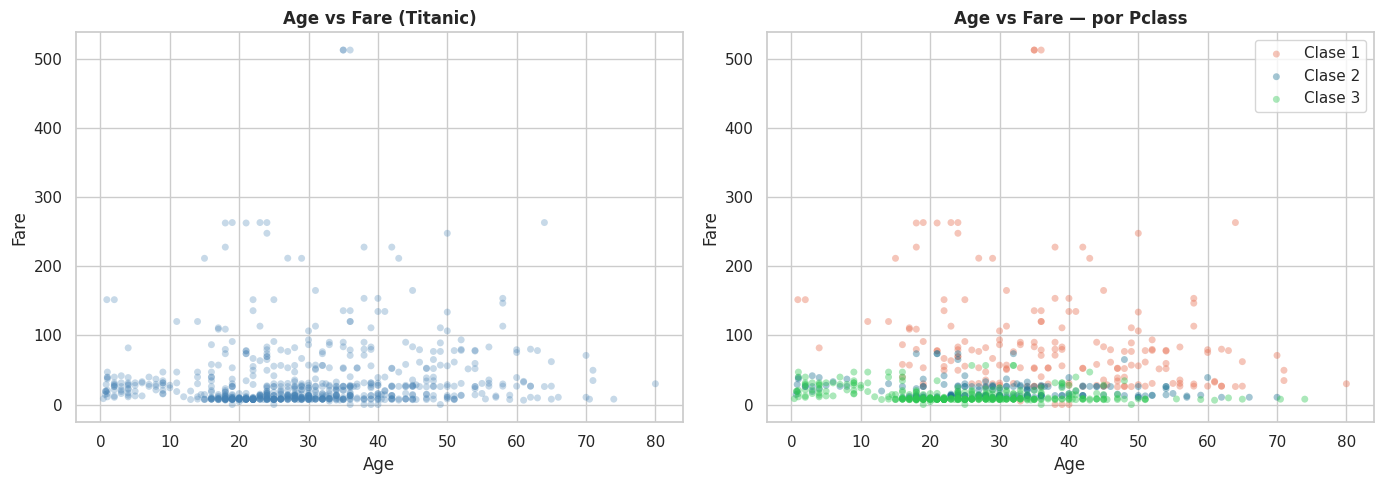

Observar: ¿hay alguna tendencia visible entre Age y Fare?


In [ ]:
# Scatter plot: Age vs Fare (Titanic)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter básico
axes[0].scatter(df['Age'].dropna(),
                df.loc[df['Age'].notna(), 'Fare'],
                alpha=0.3, color='steelblue', edgecolors='none', s=25)
axes[0].set_xlabel('Age')  ;  axes[0].set_ylabel('Fare')
axes[0].set_title('Age vs Fare (Titanic)', fontweight='bold')

# Scatter con color por clase
colors = {1:'#E76F51', 2:'#1C7293', 3:'#2DC653'}
for pclass, grupo in df.dropna(subset=['Age']).groupby('Pclass'):
    axes[1].scatter(grupo['Age'], grupo['Fare'],
                    alpha=0.4, label=f'Clase {pclass}',
                    color=colors[pclass], s=25, edgecolors='none')
axes[1].set_xlabel('Age')  ;  axes[1].set_ylabel('Fare')
axes[1].set_title('Age vs Fare — por Pclass', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Observar: ¿hay alguna tendencia visible entre Age y Fare?')

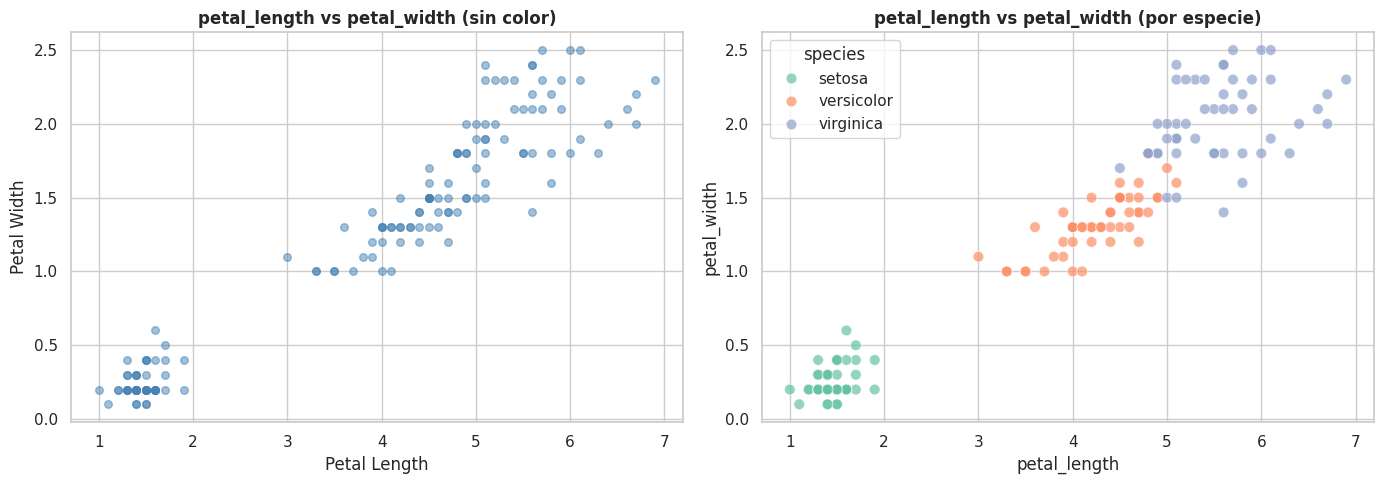

CLAVE: colorear por la variable categórica revela la estructura del dataset.


In [ ]:
# Scatter plots de Iris: petal_length vs petal_width (con color por especie)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin color por especie
axes[0].scatter(iris['petal_length'], iris['petal_width'],
                alpha=0.5, color='steelblue', s=30)
axes[0].set_xlabel('Petal Length')  ;  axes[0].set_ylabel('Petal Width')
axes[0].set_title('petal_length vs petal_width (sin color)', fontweight='bold')

# Con color por especie — revela los clusters
sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', ax=axes[1], alpha=0.7, s=60)
axes[1].set_title('petal_length vs petal_width (por especie)', fontweight='bold')

plt.tight_layout()
plt.show()

print('CLAVE: colorear por la variable categórica revela la estructura del dataset.')

---
## 📐 Sección 5: Correlación — Pearson y Spearman

In [ ]:
# Correlaciones de Pearson y Spearman para variables numéricas del Titanic
cols_num = ['Age', 'Fare', 'SibSp', 'Parch']

pearson  = df[cols_num].corr(method='pearson').round(3)
spearman = df[cols_num].corr(method='spearman').round(3)

print('Correlación de PEARSON:')
print(pearson)
print()
print('Correlación de SPEARMAN:')
print(spearman)

Correlación de PEARSON:
         Age   Fare  SibSp  Parch
Age    1.000  0.096 -0.308 -0.189
Fare   0.096  1.000  0.160  0.216
SibSp -0.308  0.160  1.000  0.415
Parch -0.189  0.216  0.415  1.000

Correlación de SPEARMAN:
         Age   Fare  SibSp  Parch
Age    1.000  0.135 -0.182 -0.254
Fare   0.135  1.000  0.447  0.410
SibSp -0.182  0.447  1.000  0.450
Parch -0.254  0.410  0.450  1.000


In [ ]:
# Comparar Pearson vs Spearman para Age-Fare
df_clean = df[['Age','Fare']].dropna()

r_pearson,  p_pearson  = stats.pearsonr(df_clean['Age'],  df_clean['Fare'])
r_spearman, p_spearman = stats.spearmanr(df_clean['Age'], df_clean['Fare'])

print('Age vs Fare:')
print(f'  Pearson:  r = {r_pearson:.4f}  |  p-valor = {p_pearson:.4f}')
print(f'  Spearman: r = {r_spearman:.4f}  |  p-valor = {p_spearman:.4f}')
print()
print('El p-valor indica si la correlación es estadísticamente significativa.')
print('p < 0.05 → correlación significativa (no es producto del azar)')

Age vs Fare:
  Pearson:  r = 0.0961  |  p-valor = 0.0102
  Spearman: r = 0.1351  |  p-valor = 0.0003

El p-valor indica si la correlación es estadísticamente significativa.
p < 0.05 → correlación significativa (no es producto del azar)


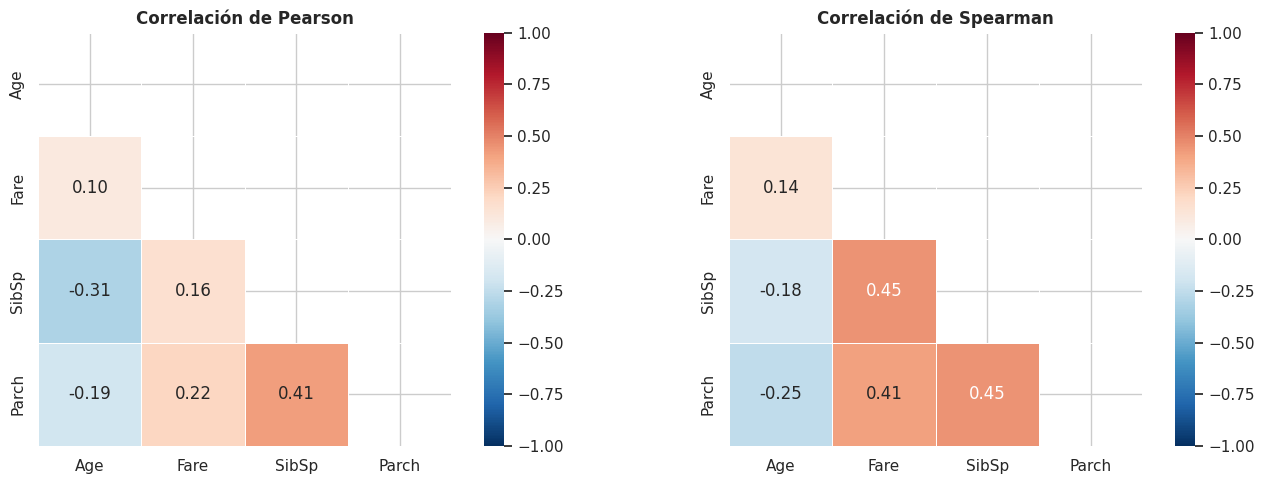

Comparar: ¿en qué pares difieren Pearson y Spearman?


In [ ]:
# Heatmap de correlación — Titanic
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Máscara para ocultar triángulo superior
mask = np.triu(np.ones_like(pearson, dtype=bool))

# Pearson
sns.heatmap(pearson, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlación de Pearson', fontweight='bold')

# Spearman
mask2 = np.triu(np.ones_like(spearman, dtype=bool))
sns.heatmap(spearman, mask=mask2, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlación de Spearman', fontweight='bold')

plt.tight_layout()
plt.show()

print('Comparar: ¿en qué pares difieren Pearson y Spearman?')

### ✏️ Actividad 3: Correlación en Iris

Calculá la matriz de correlación de Pearson para el dataset Iris (solo las 4 variables numéricas) y visualizala como heatmap.

**Preguntas:**
1. ¿Qué par de variables tiene la correlación más alta?
2. ¿Hay algún par con correlación negativa?
3. ¿Qué significa que `petal_length` y `petal_width` tengan correlación ≈ 0.96?

In [ ]:
# TODO: Calcular heatmap de correlación para Iris
# cols_iris_num = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
# corr_iris = iris[cols_iris_num].corr()
# sns.heatmap(...)
pass

---
## 📦 Sección 6: Bivariado — Numérica × Categórica

In [ ]:
# Comparar distribución de Age entre grupos de Survived
print('Estadísticas de Age por Survived:')
print(df.groupby('Survived')['Age'].describe().round(2))
print()
print('Estadísticas de Fare por Pclass:')
print(df.groupby('Pclass')['Fare'].describe().round(2))

Estadísticas de Age por Survived:
          count   mean    std   min   25%   50%   75%   max
Survived                                                   
False     424.0  30.63  14.17  1.00  21.0  28.0  39.0  74.0
True      290.0  28.34  14.95  0.42  19.0  28.0  36.0  80.0

Estadísticas de Fare por Pclass:
        count   mean    std  min    25%    50%   75%     max
Pclass                                                      
1       216.0  84.15  78.38  0.0  30.92  60.29  93.5  512.33
2       184.0  20.66  13.42  0.0  13.00  14.25  26.0   73.50
3       491.0  13.68  11.78  0.0   7.75   8.05  15.5   69.55


/tmp/ipykernel_41062/2358005697.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Pclass')['Fare'].describe().round(2))


/tmp/ipykernel_41062/4033705388.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Age', palette='Blues', ax=axes[0,0])
/tmp/ipykernel_41062/4033705388.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Pclass', y='Age', palette='Blues',
/tmp/ipykernel_41062/4033705388.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Oranges', ax=axes[1,1])


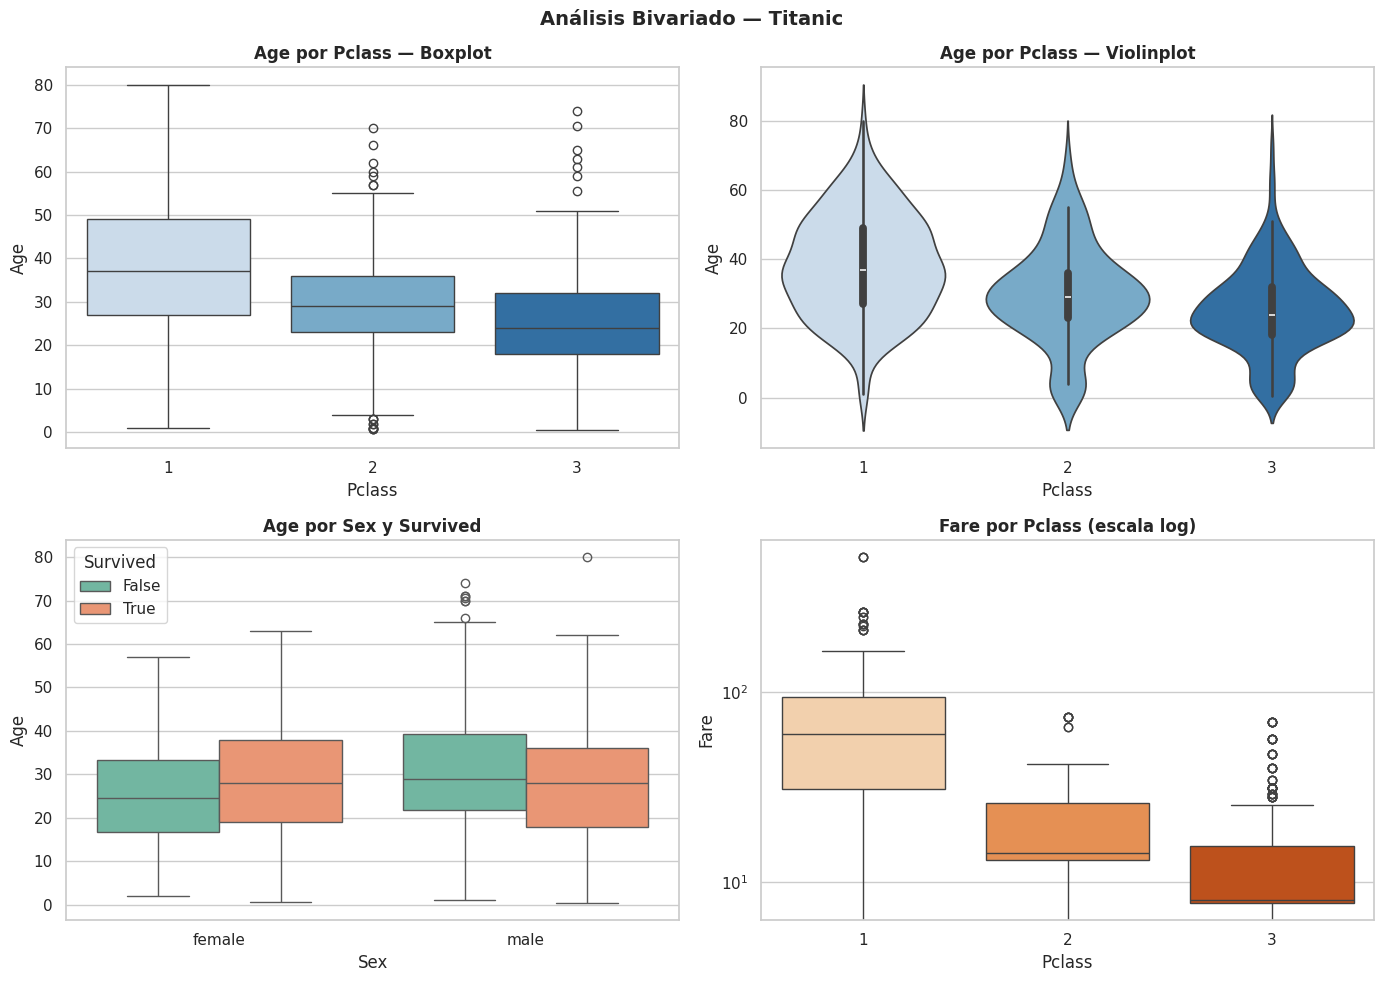

In [ ]:
# Boxplot y violinplot comparativos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age por Pclass
sns.boxplot(data=df, x='Pclass', y='Age', palette='Blues', ax=axes[0,0])
axes[0,0].set_title('Age por Pclass — Boxplot', fontweight='bold')

# Age por Pclass — violinplot
sns.violinplot(data=df, x='Pclass', y='Age', palette='Blues',
               inner='box', ax=axes[0,1])
axes[0,1].set_title('Age por Pclass — Violinplot', fontweight='bold')

# Age por Sex con hue=Survived
sns.boxplot(data=df, x='Sex', y='Age', hue='Survived',
            palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Age por Sex y Survived', fontweight='bold')

# Fare por Pclass (log scale)
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Oranges', ax=axes[1,1])
axes[1,1].set_yscale('log')
axes[1,1].set_title('Fare por Pclass (escala log)', fontweight='bold')

plt.suptitle('Análisis Bivariado — Titanic', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1306/1644265550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=iris, x='species', y='petal_length',
/tmp/ipykernel_1306/1644265550.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y='petal_width',


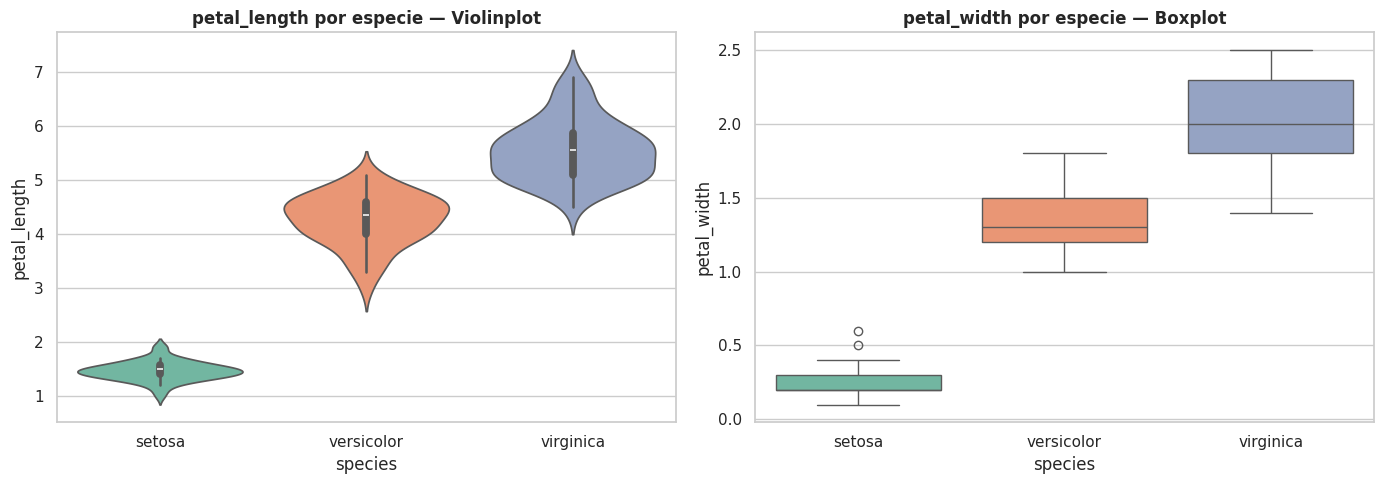

OBSERVAR: ¿Las distribuciones se superponen entre especies?
Cuanto menos se superponen, mejor predictor es esa variable.


In [ ]:
# Violinplot de Iris: petal_length por especie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=iris, x='species', y='petal_length',
               palette='Set2', inner='box', ax=axes[0])
axes[0].set_title('petal_length por especie — Violinplot', fontweight='bold')

sns.boxplot(data=iris, x='species', y='petal_width',
            palette='Set2', ax=axes[1])
axes[1].set_title('petal_width por especie — Boxplot', fontweight='bold')

plt.tight_layout()
plt.show()

print('OBSERVAR: ¿Las distribuciones se superponen entre especies?')
print('Cuanto menos se superponen, mejor predictor es esa variable.')

---
## 🗂️ Sección 7: Bivariado — Categórica × Categórica

In [ ]:
# Tabla de contingencia: Sex x Survived
print('=== Tabla de frecuencias absolutas ===')
print(pd.crosstab(df['Sex'], df['Survived'], margins=True))
print()

print('=== Tabla normalizada (por fila = tasa de supervivencia) ===')
tabla_norm = pd.crosstab(df['Sex'], df['Survived'], normalize='index').round(3)
tabla_norm.columns = ['No sobrevivió', 'Sobrevivió']
print((tabla_norm * 100).round(1).astype(str) + '%')

=== Tabla de frecuencias absolutas ===
Survived  False  True  All
Sex                       
female       81   233  314
male        468   109  577
All         549   342  891

=== Tabla normalizada (por fila = tasa de supervivencia) ===
       No sobrevivió Sobrevivió
Sex                            
female         25.8%      74.2%
male           81.1%      18.9%


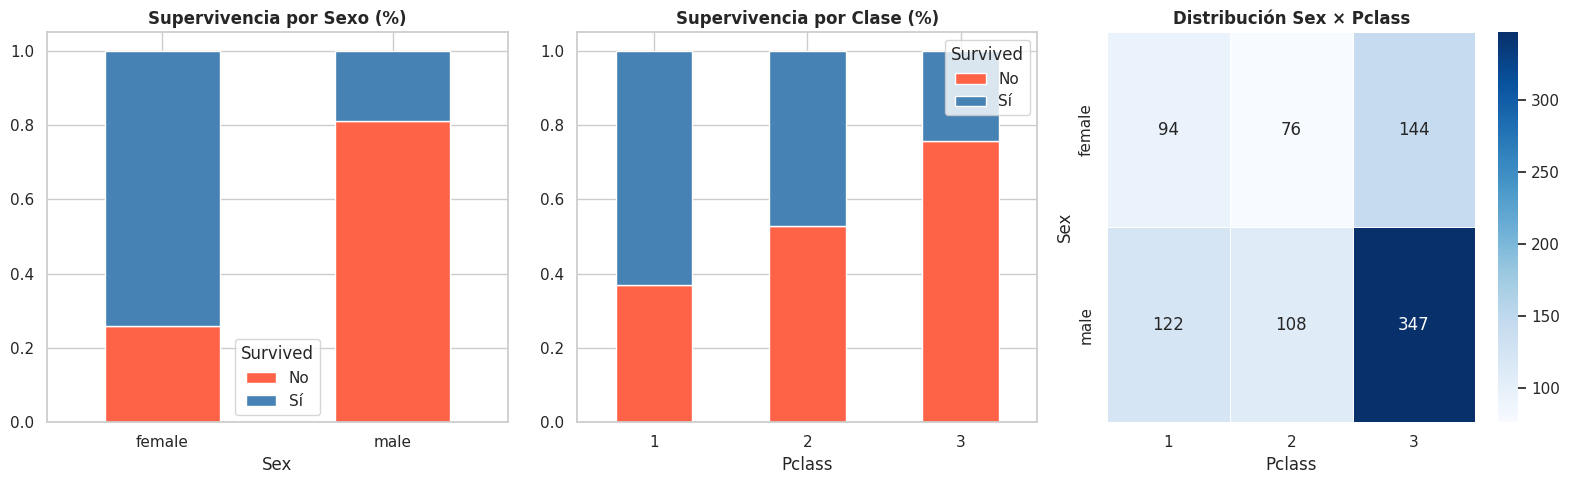

In [ ]:
# Visualización: stacked bar + heatmap de crosstab
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Stacked bar: Sex x Survived
tabla_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index')
tabla_sex.plot(kind='bar', stacked=True, ax=axes[0],
               color=['tomato','steelblue'], edgecolor='white')
axes[0].set_title('Supervivencia por Sexo (%)', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['No', 'Sí'], title='Survived')

# Stacked bar: Pclass x Survived
tabla_pclass = pd.crosstab(df['Pclass'], df['Survived'], normalize='index')
tabla_pclass.plot(kind='bar', stacked=True, ax=axes[1],
                  color=['tomato','steelblue'], edgecolor='white')
axes[1].set_title('Supervivencia por Clase (%)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['No', 'Sí'], title='Survived')

# Heatmap: Sex x Pclass
sns.heatmap(pd.crosstab(df['Sex'], df['Pclass']),
            annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[2])
axes[2].set_title('Distribución Sex × Pclass', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🔭 Sección 8: Pairplot — análisis multivariado completo

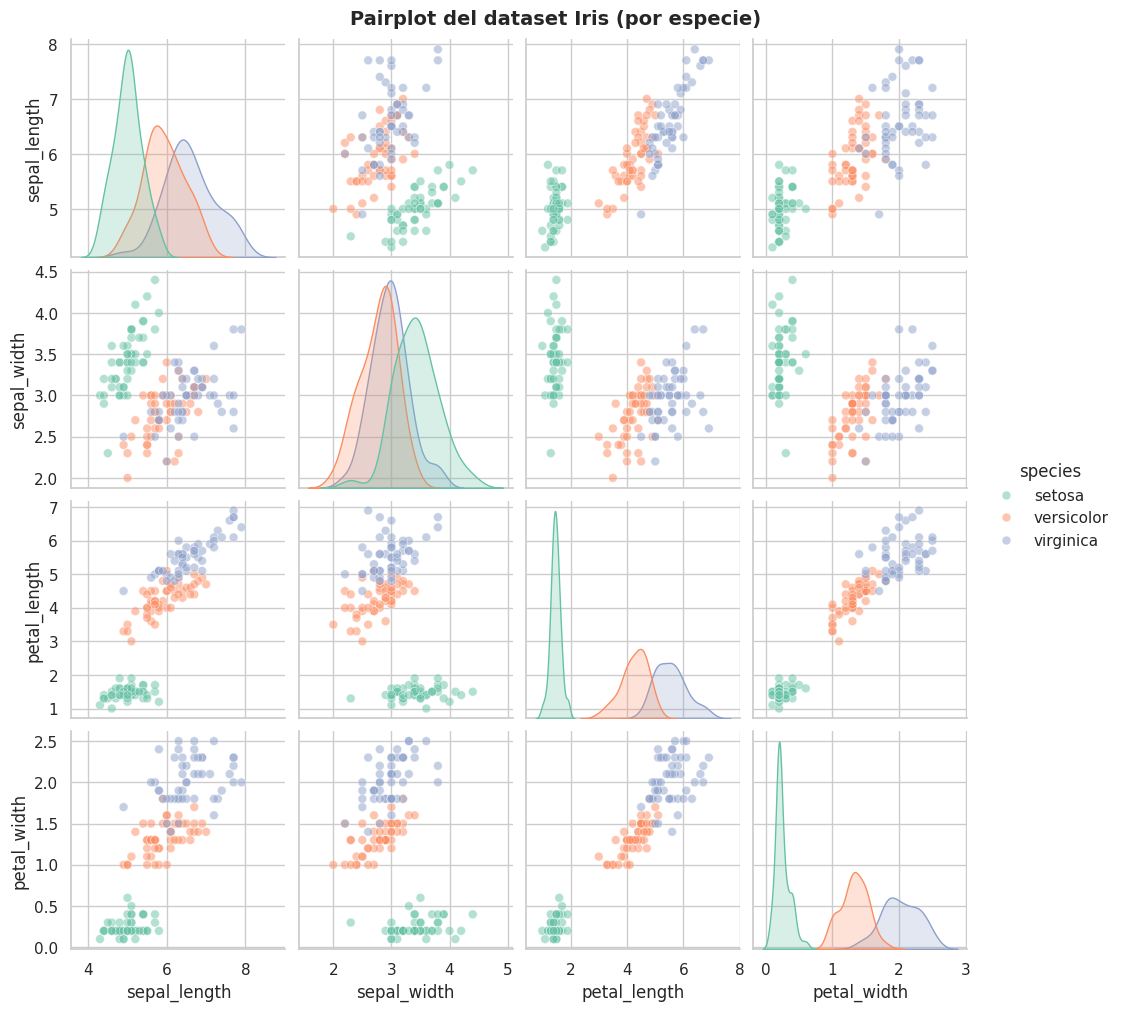

INTERPRETAR:
  - Diagonal: distribución de cada variable por especie
  - Cada celda off-diagonal: scatter de un par de variables
  - Color: especie


In [ ]:
# Pairplot del dataset Iris (el ejemplo clásico)
# Esto puede tardar unos segundos en renderizar
g = sns.pairplot(
    iris,
    hue='species',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 40}
)
g.fig.suptitle('Pairplot del dataset Iris (por especie)', y=1.01,
               fontweight='bold', fontsize=14)
plt.show()

print('INTERPRETAR:')
print('  - Diagonal: distribución de cada variable por especie')
print('  - Cada celda off-diagonal: scatter de un par de variables')
print('  - Color: especie')

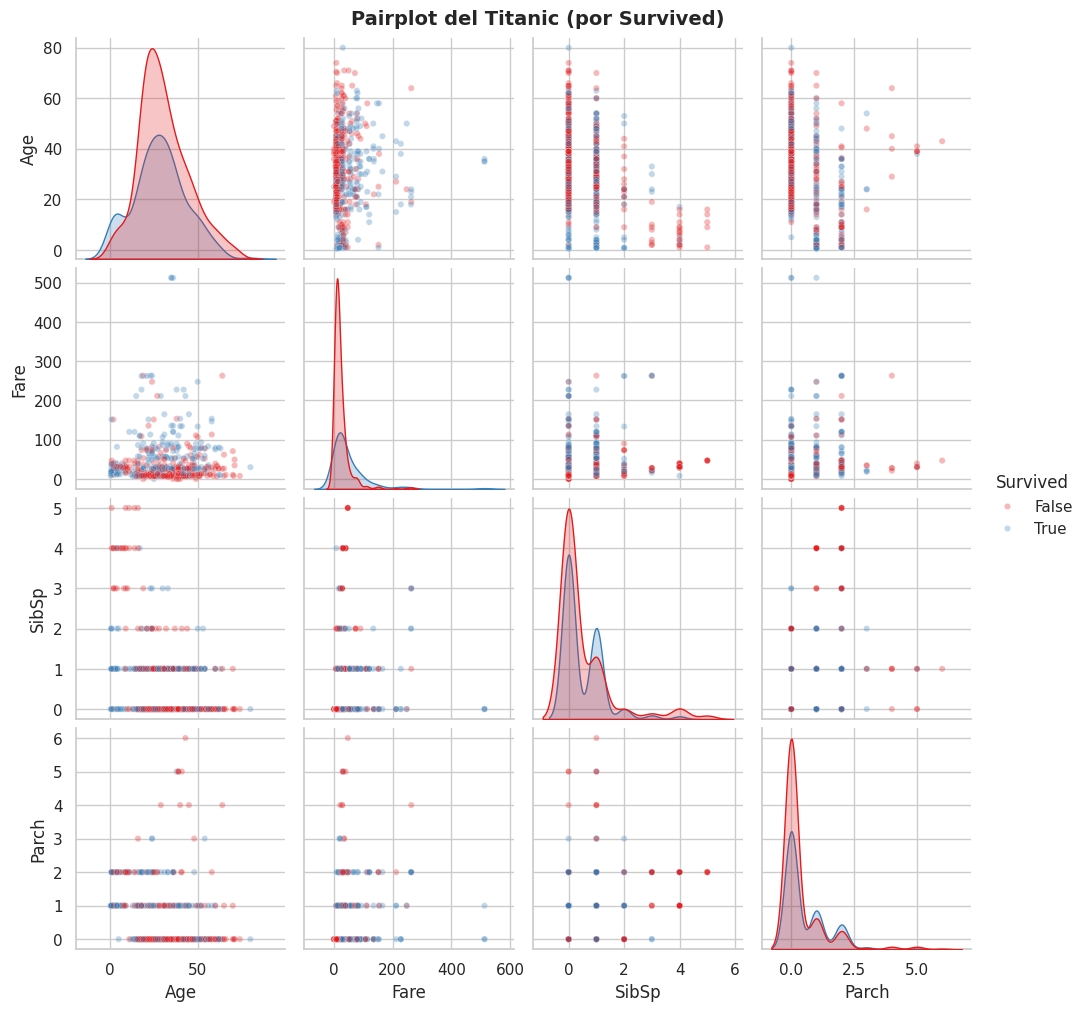

¿Se ve alguna separación entre sobrevivientes (rojo) y no sobrevivientes (azul)?


In [ ]:
# Pairplot del Titanic (variables numéricas)
cols_titanic = ['Age', 'Fare', 'SibSp', 'Parch']
df_pairplot = df[cols_titanic + ['Survived']].dropna()

g2 = sns.pairplot(
    df_pairplot,
    hue='Survived',
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 20},
    palette='Set1'
)
g2.fig.suptitle('Pairplot del Titanic (por Survived)', y=1.01,
                fontweight='bold', fontsize=14)
plt.show()

print('¿Se ve alguna separación entre sobrevivientes (rojo) y no sobrevivientes (azul)?')

### ✏️ Actividad 4: Interpretar el pairplot de Iris

Mirando el pairplot de Iris, respondé:

1. ¿Qué par de variables separa mejor las tres especies? (Pista: buscá el scatter donde los colores no se superponen)
2. `setosa` (azul): ¿está bien separada de las otras dos especies en todos los gráficos?
3. `versicolor` y `virginica`: ¿se superponen mucho o poco?
4. En la diagonal (distribuciones): ¿qué variable tiene las distribuciones más separadas por especie?

*Escribí tus respuestas aquí.*

---
## 👥 Sección 9: Análisis por grupos — groupby avanzado

In [ ]:
# Análisis multivariado con groupby
resumen_multi = df.groupby(['Pclass', 'Sex']).agg(
    n_pasajeros=('PassengerId', 'count'),
    age_media=('Age', 'mean'),
    fare_media=('Fare', 'mean'),
    tasa_supervivencia=('Survived', 'mean')
).round(2)

print('Estadísticas por Pclass y Sex:')
print(resumen_multi)

Estadísticas por Pclass y Sex:
               n_pasajeros  age_media  fare_media  tasa_supervivencia
Pclass Sex                                                           
1      female           94      34.61      106.13                0.97
       male            122      41.28       67.23                0.37
2      female           76      28.72       21.97                0.92
       male            108      30.74       19.74                0.16
3      female          144      21.75       16.12                0.50
       male            347      26.51       12.66                0.14


/tmp/ipykernel_1306/4213756370.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_multi = df.groupby(['Pclass', 'Sex']).agg(


/tmp/ipykernel_1306/2329524890.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100


<Figure size 800x500 with 0 Axes>

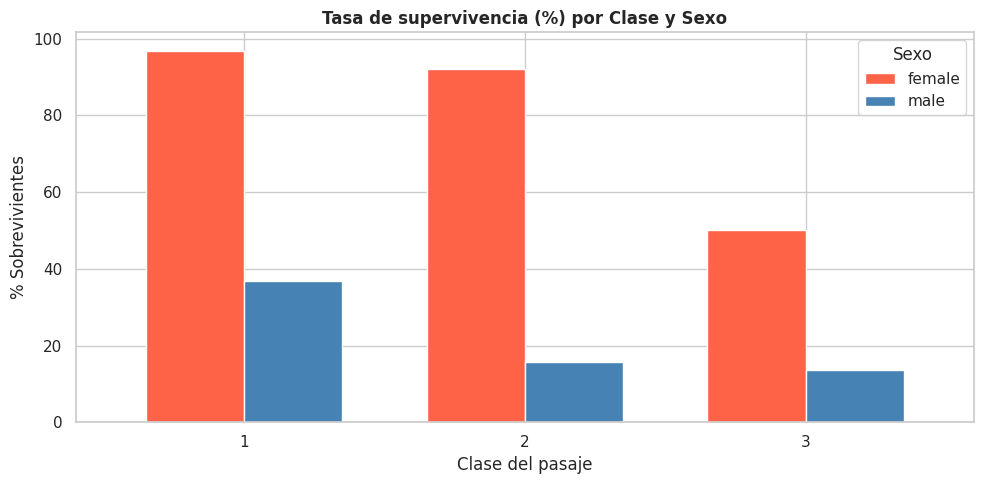

Este gráfico resume el patrón más importante del Titanic.


In [ ]:
# Visualizar tasa de supervivencia por Pclass y Sex
# Crear tabla pivot
pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100

plt.figure(figsize=(8, 5))
pivot.plot(kind='bar', color=['tomato','steelblue'],
           edgecolor='white', width=0.7)
plt.title('Tasa de supervivencia (%) por Clase y Sexo', fontweight='bold')
plt.ylabel('% Sobrevivientes')
plt.xlabel('Clase del pasaje')
plt.xticks(rotation=0)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

print('Este gráfico resume el patrón más importante del Titanic.')

---
## 🎯 Actividad Integradora: EDA completo del dataset Iris

Aplicá todas las técnicas del laboratorio sobre el dataset Iris.

### Instrucciones
Seguí las 6 etapas del EDA que vimos en la clase teórica:

| Etapa | Tarea |
|-------|-------|
| 1. Inspección inicial | head(), info(), shape, dtypes |
| 2. Calidad de datos | nulos, duplicados, rangos posibles |
| 3. Univariado | `eda_columna()` para cada variable numérica |
| 4. Multivariado | correlaciones + heatmap + pairplot |
| 5. Anomalías | detectar_outliers() para petal_length |
| 6. Síntesis | Escribir 5 hallazgos concretos |

---

In [ ]:
# ETAPA 1: Inspección inicial
print('Shape:', iris.shape)
print()
iris.head()

Shape: (150, 5)



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# ETAPA 1: info() y dtypes
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# ETAPA 2: Calidad de datos
print('Nulos por columna:')
print(iris.isnull().sum())
print()
print('Duplicados:', iris.duplicated().sum())
print()
print('Valores únicos de species:', iris['species'].unique())

Nulos por columna:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicados: 1

Valores únicos de species: ['setosa' 'versicolor' 'virginica']


In [ ]:
# ETAPA 3: Análisis univariado
# TODO: Aplicar eda_columna() a las 4 variables numéricas de Iris
# for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
#     eda_columna(iris, col)
pass

In [ ]:
# ETAPA 3: Análisis univariado de 'species'
# TODO: Aplicar eda_columna() a species
pass

In [ ]:
# ETAPA 4: Correlaciones + heatmap
# TODO: Calcular y visualizar la matriz de correlación del dataset Iris
pass

In [ ]:
# ETAPA 4: Pairplot con color por species
# TODO: Generar el pairplot del dataset Iris coloreando por especie
pass

In [ ]:
# ETAPA 5: Detección de outliers
# Reutilizamos la función del laboratorio de U2
def detectar_outliers(df, col):
    serie = df[col].dropna()
    Q1 = serie.quantile(0.25)  ;  Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR  ;  lim_sup = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    print(f'Columna: {col}  |  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
    return outliers

# TODO: Aplicar a las 4 columnas numéricas de Iris
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    detectar_outliers(iris, col)

Columna: sepal_length  |  Outliers: 0 (0.0%)
Columna: sepal_width  |  Outliers: 4 (2.7%)
Columna: petal_length  |  Outliers: 0 (0.0%)
Columna: petal_width  |  Outliers: 0 (0.0%)


### ETAPA 6: Síntesis de hallazgos

Escribí 5 hallazgos concretos del EDA sobre Iris. Seguí este formato:

*Ejemplo: 'petal_length y petal_width tienen correlación de Pearson = 0.96, indicando una relación lineal muy fuerte entre ambas variables.'*

1. ...
2. ...
3. ...
4. ...
5. ...

---
## 📋 Resumen: técnicas y funciones del laboratorio

| Técnica | Función | ¿Cuándo? |
|---------|---------|----------|
| Sesgo y curtosis | `.skew()`, `.kurtosis()` | Entender la forma de la distribución |
| EDA univariado numérico | `eda_columna()` | Exploración inicial de cada variable |
| Scatter plot | `plt.scatter()`, `sns.regplot()` | Numérica × Numérica |
| Correlación Pearson | `.corr(method='pearson')` | Relación lineal entre numéricas |
| Correlación Spearman | `.corr(method='spearman')` | Relación monotónica o con outliers |
| Heatmap de correlación | `sns.heatmap()` | Visualizar todas las correlaciones |
| Pairplot | `sns.pairplot()` | Exploración multivariada completa |
| Boxplot comparativo | `sns.boxplot(hue=cat)` | Numérica × Categórica |
| Violinplot | `sns.violinplot()` | Numérica × Categórica con más detalle |
| Tabla de contingencia | `pd.crosstab()` | Categórica × Categórica |
| Análisis por grupos | `df.groupby().agg()` | Estadísticas por segmento |

---
**Próxima clase — Unidad 4:** Visualización de Datos
- Matplotlib en profundidad: personalización, subplots, estilos
- Seaborn: galería completa de gráficos
- Principios de diseño visual para datos

*Completar todas las actividades TODO antes de la próxima clase.*